Capstone Project: ML-Driven Decision Support for “Aurora Finance”
Scenario: Aurora Finance is a fictitious mid-size financial services firm that does corporate lending, manages investments, and trades derivatives. They want to leverage ML for better decision-making across the firm:

Which corporate projects to fund
How to price loans and assess credit risk
Where to invest and construct portfolios
How to monitor and hedge derivative exposures Students will act as “Data & ML Strategy Consultants”, integrating ML insights into financial decision-making.
Step 1: Corporate Finance Module Objective: Decide which internal projects Aurora should fund. Data Provided / Simulated:

Historical corporate projects: investment amount, expected cash flows, duration, risk rating, department, past ROI
Market indicators: GDP growth, sector-specific trends Tasks:
Forecast project cash flows using regression / ML (e.g., XGBoost / Random Forest)
Predict project success probability / IRR using classification or risk scoring
Recommend top projects based on expected economic value (EV) and risk-adjusted return Deliverables:
Ranked project list
SHAP plots / decision explanation for executives
Brief summary of recommendations

In [ ]:
#Data Exploration

In [ ]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

file_path = '/content/sample_data/corporate_projects.csv'
df = pd.read_csv(file_path)
print("Original DataFrame Info:")
df.info()

# Perform one-hot encoding for 'Department', dropping the first category
department_dummies = pd.get_dummies(df['Department'], prefix='Department', drop_first=True)

# Perform Ordinal Encoding for 'Project_Risk'
# Define the order of categories
risk_categories = ['Low', 'Medium', 'High']

ordinal_encoder = OrdinalEncoder(categories=[risk_categories])
# Apply encoding to the 'Project_Risk' column and store it as a separate DataFrame
project_risk_encoded_df = pd.DataFrame(
    ordinal_encoder.fit_transform(df[['Project_Risk']]),
    columns=['Project_Risk_Encoded'],
    index=df.index
)

# Convert the encoded column to integer type
project_risk_encoded_df['Project_Risk_Encoded'] = project_risk_encoded_df['Project_Risk_Encoded'].astype(int)

# Concatenate the new dummy variables and the ordinal encoded column with the original DataFrame,
# after dropping the original 'Department' and 'Project_Risk' columns
df = pd.concat([
    df.drop(columns=['Department', 'Project_Risk']),
    department_dummies,
    project_risk_encoded_df
], axis=1)

print("\nDataFrame Info after Encoding:")
df.info()
print("\nFirst 5 rows after Encoding:")
display(df.head())

Original DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Project_ID               50 non-null     int64  
 1   Department               50 non-null     object 
 2   Investment_Cost          50 non-null     int64  
 3   Expected_Cashflow_Year1  50 non-null     int64  
 4   Expected_Cashflow_Year2  50 non-null     int64  
 5   Expected_Cashflow_Year3  50 non-null     int64  
 6   Historical_ROI           50 non-null     float64
 7   Market_Growth            50 non-null     float64
 8   Project_Risk             50 non-null     object 
 9   Success                  50 non-null     int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 4.0+ KB

DataFrame Info after Encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 12 columns):
 #   Column                

,Project_ID,Investment_Cost,Expected_Cashflow_Year1,Expected_Cashflow_Year2,Expected_Cashflow_Year3,Historical_ROI,Market_Growth,Success,Department_IT,Department_Marketing,Department_Operations,Project_Risk_Encoded
0,1,184654,583556,2348816,1888756,0.08,0.05,0,False,False,True,0
1,2,2054354,1447527,541234,278576,0.15,-0.01,1,False,True,False,0
2,3,2516182,1372905,1998260,2312990,0.19,0.02,1,False,False,False,2
3,4,3574675,1817640,189182,1434250,0.22,0.10,1,False,False,True,1
4,5,2752991,792139,1571101,111087,0.12,0.09,0,False,False,True,2


In [337]:
# Calculate Total_Expected_Cashflow as the sum of cash flows from all years
df['Total_Expected_Cashflow'] = df['Expected_Cashflow_Year1'] + df['Expected_Cashflow_Year2'] + df['Expected_Cashflow_Year3']

# Calculate ROI_Amount as Investment_Cost * Historical_ROI
df['ROI_Amount'] = df['Investment_Cost'] * df['Historical_ROI']

# Calculate Profit
df['NPV'] = (
    df['Expected_Cashflow_Year1'] / (1 + df['Historical_ROI'])**1 +
    df['Expected_Cashflow_Year2'] / (1 + df['Historical_ROI'])**2 +
    df['Expected_Cashflow_Year3'] / (1 + df['Historical_ROI'])**3 -
    df['Investment_Cost']
)

# Calculate Market_Growth_Factor
df['Market_Growth_Factor'] = (1 + df['Market_Growth']).pow(3)

# Calculate FutureCashFlow
df['FutureCashFlow'] = (df['ROI_Amount'] * df['Market_Growth_Factor'])
df['NPV'] = df['ROI_Amount'] - df['Investment_Cost']

# Calculate ROT_Amount based on Total_Expected_Cashflow and Investment_Cost
# (Assuming ROT_Amount is intended to be Total_Expected_Cashflow / Investment_Cost if Investment_Cost is not zero)
# You might need to adjust this calculation based on the precise definition of ROT_Amount.
# For now, let's assume it's a simple ratio.
#df['ROT_Amount'] = df.apply(lambda row: row['Total_Expected_Cashflow'] / row['Investment_Cost'] if row['Investment_Cost'] != 0 else 0, axis=1)


# Display the updated DataFrame with new features
print("DataFrame with new features (Total_Expected_Cashflow, ROI_Amount, Profit, Market_Growth_Factor, FutureCashFlow, ROT_Amount):")
display(df.head())

DataFrame with new features (Total_Expected_Cashflow, ROI_Amount, Profit, Market_Growth_Factor, FutureCashFlow, ROT_Amount):


,Project_ID,Investment_Cost,Expected_Cashflow_Year1,Expected_Cashflow_Year2,Expected_Cashflow_Year3,Historical_ROI,Market_Growth,Success,Department_IT,Department_Marketing,Department_Operations,Project_Risk_Encoded,Total_Expected_Cashflow,ROI_Amount,Profit,Market_Growth_Factor,FutureCashFlow,NPV,IRR
0,1,184654,583556,2348816,1888756,0.08,0.05,0,False,False,True,0,4821128,14772.32,-169881.68,1.157625,1.710081e+04,-169881.68,NaN
1,2,2054354,1447527,541234,278576,0.15,-0.01,1,False,True,False,0,2267337,308153.10,-1746200.90,0.970299,2.990006e+05,-1746200.90,NaN
2,3,2516182,1372905,1998260,2312990,0.19,0.02,1,False,False,False,2,5684155,478074.58,-2038107.42,1.061208,5.073366e+05,-2038107.42,NaN
3,4,3574675,1817640,189182,1434250,0.22,0.10,1,False,False,True,1,3441072,786428.50,-2788246.50,1.331000,1.046736e+06,-2788246.50,NaN
4,5,2752991,792139,1571101,111087,0.12,0.09,0,False,False,True,2,2474327,330358.92,-2422632.08,1.295029,4.278244e+05,-2422632.08,NaN


In [ ]:
# Create a new feature for Risk-Adjusted Cashflow
# Divide Total_Expected_Cashflow by Project_Risk_Encoded + 1
# Adding 1 to Project_Risk_Encoded ensures no division by zero and that higher risk (higher encoded value)
# results in a lower adjusted cashflow.
df['Risk_Adjusted_Cashflow'] = df['Total_Expected_Cashflow'] / (df['Project_Risk_Encoded'] + 1)

print("DataFrame with 'Risk_Adjusted_Cashflow' feature:")
display(df[['Project_ID', 'Total_Expected_Cashflow', 'Project_Risk_Encoded', 'Risk_Adjusted_Cashflow']].head())

DataFrame with 'Risk_Adjusted_Cashflow' feature:


,Project_ID,Total_Expected_Cashflow,Project_Risk_Encoded,Risk_Adjusted_Cashflow
0,1,4821128,0,4.821128e+06
1,2,2267337,0,2.267337e+06
2,3,5684155,2,1.894718e+06
3,4,3441072,1,1.720536e+06
4,5,2474327,2,8.247757e+05


### Suggested New Engineered Features

### Department-wise Project Count

In [ ]:
department_counts = {
    'IT': df['Department_IT'].sum(),
    'Marketing': df['Department_Marketing'].sum(),
    'Operations': df['Department_Operations'].sum()
}

department_counts_df = pd.DataFrame(department_counts.items(), columns=['Department', 'Number_of_Projects'])

print("Number of projects per department:")
display(department_counts_df)

Number of projects per department:


,Department,Number_of_Projects
0,IT,11
1,Marketing,16
2,Operations,13


### Feature Correlation Heatmap

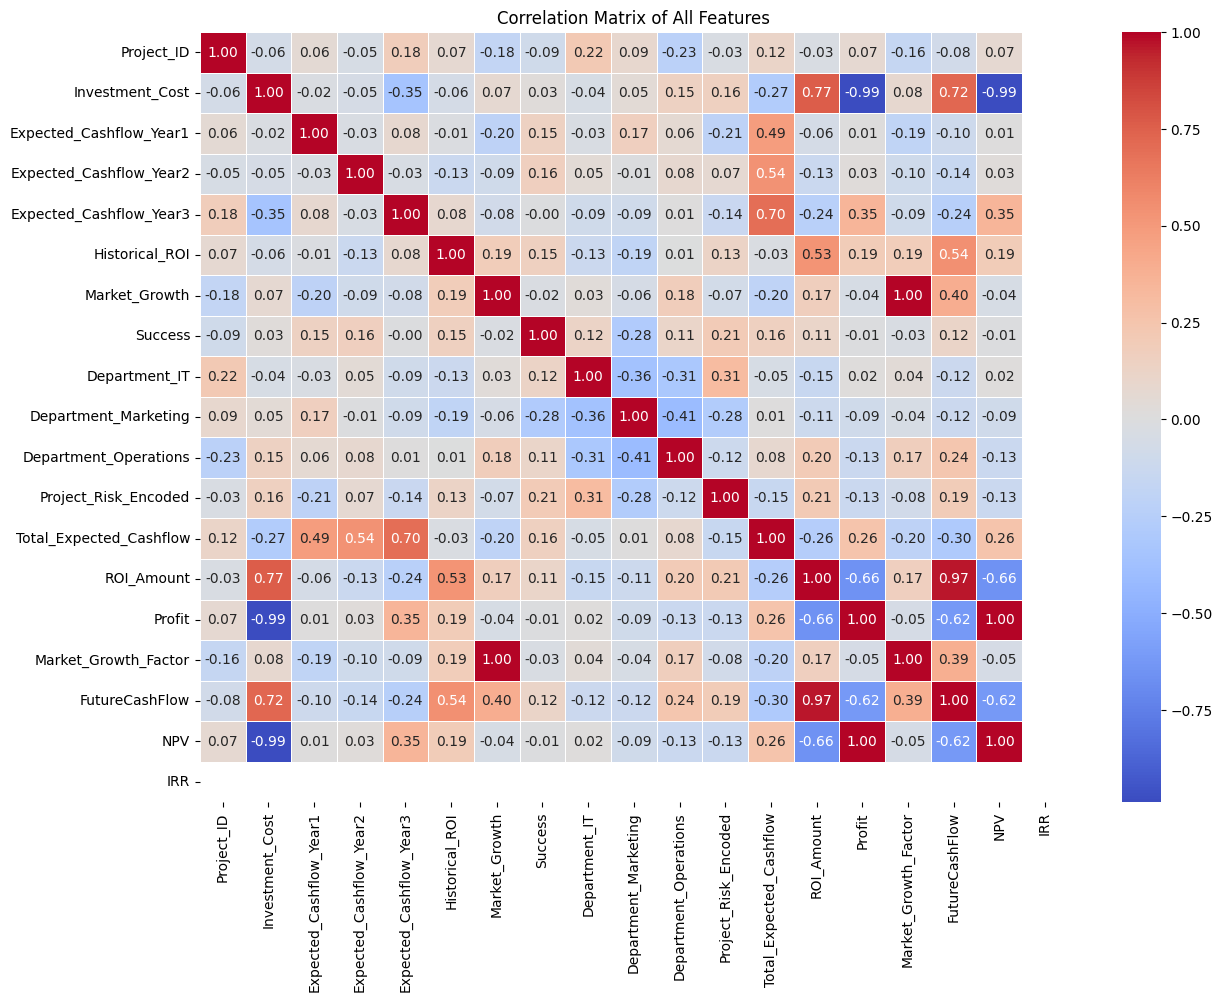

In [338]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for all features
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Features')
plt.show()

### Predicting `Total_Expected_Cashflow` using `ROI_Amount` and `ROT_Amount` with RandomForestRegressor

In [343]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
X_new_features = df[['Investment_Cost','Historical_ROI','Market_Growth','Success']]
y_target = df['NPV']

# Split the data into training and testing sets
X_train_new_rf, X_test_new_rf, y_train_new_rf, y_test_new_rf = train_test_split(
    X_new_features, y_target, test_size=0.2, random_state=42
)

# Initialize and train the RandomForestRegressor
rf_model_new_features = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_new_features.fit(X_train_new_rf, y_train_new_rf)

# Make predictions on the test set
y_pred_new_rf = rf_model_new_features.predict(X_test_new_rf)

# Evaluate the model's performance
mae_new_rf = mean_absolute_error(y_test_new_rf, y_pred_new_rf)
mse_new_rf = mean_squared_error(y_test_new_rf, y_pred_new_rf)
rmse_new_rf = np.sqrt(mse_new_rf)
r2_new_rf = r2_score(y_test_new_rf, y_pred_new_rf)

print(f"RandomForestRegressor Performance with ROI_Amount and ROT_Amount:")
print(f"Mean Absolute Error (MAE): {mae_new_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_new_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_new_rf:.2f}")
print(f"R-squared (R2): {r2_new_rf:.2f}")

# Display actual vs. predicted values
results_new_rf_df = pd.DataFrame({'Actual': y_test_new_rf, 'Predicted': y_pred_new_rf})
display(results_new_rf_df.head())

RandomForestRegressor Performance with ROI_Amount and ROT_Amount:
Mean Absolute Error (MAE): 196688.11
Mean Squared Error (MSE): 67564949738.62
Root Mean Squared Error (RMSE): 259932.59
R-squared (R2): 0.93


,Actual,Predicted
13,-2258500.14,-2.701951e+06
39,-2612227.46,-2.781252e+06
30,-301187.16,-2.225675e+05
45,-941199.05,-1.008568e+06
17,-2390373.72,-2.505872e+06


### Evaluating the RandomForestRegressor Model

In [345]:
print(f"RandomForestRegressor Performance with ROI_Amount and ROT_Amount (on Test Set):")
print(f"Mean Absolute Error (MAE): {mae_new_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_new_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_new_rf:.2f}")
print(f"R-squared (R2): {r2_new_rf:.2f}")

results_new_rf_df = pd.DataFrame({'Actual': y_test_new_rf, 'Predicted': y_pred_new_rf})
display(results_new_rf_df.head())

RandomForestRegressor Performance with ROI_Amount and ROT_Amount (on Test Set):
Mean Absolute Error (MAE): 196688.11
Mean Squared Error (MSE): 67564949738.62
Root Mean Squared Error (RMSE): 259932.59
R-squared (R2): 0.93


,Actual,Predicted
13,-2258500.14,-2.701951e+06
39,-2612227.46,-2.781252e+06
30,-301187.16,-2.225675e+05
45,-941199.05,-1.008568e+06
17,-2390373.72,-2.505872e+06


The RandomForestRegressor model performed well on the test set, achieving a high R-squared value of 0.93, indicating that a significant portion of the variance in `NPV` is explained by the features. The MAE, MSE, and RMSE values provide a measure of the model's error in predicting `NPV`.

### Internal Rate of Return (IRR) Calculation